# Imports and Hardware setup

This cell will initialize PyTorch and insures that this computer(Mac)'s GPU[Metal Performance Shaders] will handle the training load.

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import math
import numpy as np

# Route to Apple Silicon GPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("- Metal Performance Shaders (MPS) backend enabled! Training on Mac GPU.")
else:
    device = torch.device("cpu")
    print("- MPS not found. Defaulting to CPU.")

- Metal Performance Shaders (MPS) backend enabled! Training on Mac GPU.


# Load the Processed Dataset

This will pull *.pt* file we created in the data preprocessing notebook and splits it into training and testing batches.

In [38]:
PROCESSED_DATA_PATH = "./processed_mosquito_dataset.pt"
BATCH_SIZE = 32

print("Loading dataset into memory...")
full_dataset = torch.load(PROCESSED_DATA_PATH, weights_only=False)

# Train/Test Split (80% Train, 20% Test)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches: {len(test_loader)}")

Loading dataset into memory...
Training batches: 82
Testing batches: 21


# The SincNet Math (Custom Layer)

This is the core of the SincNet paper. Instead of normal CNN weights, this layer defines a low-pass and high-pass frequency and uses the mathematical Sinc function to create a band-pass filter. The neural network will learn to adjust these frequency bands to isolate the mosquito hums automatically.

In [39]:
class SincConv1d(nn.Module):
    def __init__(self, out_channels, kernel_size, sample_rate=8000):
        super(SincConv1d, self).__init__()
        self.out_channels = out_channels
        self.kernel_size = kernel_size if kernel_size % 2 != 0 else kernel_size + 1
        self.sample_rate = sample_rate

        # Initialize low cutoff frequency randomly between 300 Hz and 1000 Hz
        self.low_hz_ = nn.Parameter(torch.rand(out_channels, 1) * 0.175 + 0.075)
        # Initialize filter bandwidth to be narrow (between 50 Hz and 200 Hz wide)
        # to isolate specific wingbeat harmonics
        self.band_hz_ = nn.Parameter(torch.rand(out_channels, 1) * 0.0375 + 0.0125)

        # Create a Hamming window to smooth the filter edges
        n_lin = torch.linspace(0, (self.kernel_size / 2) - 1, steps=int(self.kernel_size / 2))
        self.window_ = 0.54 - 0.46 * torch.cos(2 * math.pi * n_lin / self.kernel_size)
        
        # Time axis for the sinc function
        n = (self.kernel_size - 1) / 2.0
        self.n_ = 2 * math.pi * torch.arange(-n, 0).view(1, -1) / self.sample_rate

    def forward(self, waveforms):
        self.n_ = self.n_.to(waveforms.device)
        self.window_ = self.window_.to(waveforms.device)

        # Ensure frequencies stay within valid bounds (0 to Nyquist limit)
        low = torch.clamp(self.low_hz_, min=1e-4, max=0.49) * self.sample_rate / 2
        high = torch.clamp(low + self.band_hz_ * self.sample_rate / 2, min=1e-4, max=self.sample_rate / 2)

        # MPS-compatible manual sinc calculation: sin(pi * x) / (pi * x)
        def custom_sinc(x):
            pi_x = math.pi * x
            return torch.sin(pi_x) / pi_x

        # Generate the left side of the band-pass filter using the custom sinc function
        band_pass_left = ((2 * high * custom_sinc(2 * high * self.n_ / self.sample_rate)) - \
                         (2 * low * custom_sinc(2 * low * self.n_ / self.sample_rate))) * self.window_

        # Define the center of the filter
        band_pass_center = 2 * (high - low)

        # Mirror the left side to create the right side (filters must be symmetric)
        band_pass_right = torch.flip(band_pass_left, dims=[1])

        # Combine into the final 1D filter kernel
        filters = torch.cat([band_pass_left, band_pass_center, band_pass_right], dim=1)
        filters = filters.view(self.out_channels, 1, self.kernel_size)

        # Apply the dynamic filters to the raw audio
        return F.conv1d(waveforms, filters, stride=1, padding=self.kernel_size // 2)

# The Full Architecture

This combines the Sinc layer with standard Convolutional layers (to extract spatial patterns) and an LSTM (to track the rhythm of the wingbeats over the 1-second clip) as we prepared our data.

In [40]:
class MosquitoSincNet(nn.Module):
    def __init__(self, num_classes):
        super(MosquitoSincNet, self).__init__()
        
        # 1. Sinc Layer
        self.sinc = SincConv1d(out_channels=64, kernel_size=251)
        self.pool1 = nn.MaxPool1d(4) # Increased pooling
        
        # 2. First Spatial CNN
        self.conv1 = nn.Conv1d(in_channels=64, out_channels=64, kernel_size=5)
        self.pool2 = nn.MaxPool1d(4) # Increased pooling
        
        # 3. Second Spatial CNN (Further sequence compression)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=64, kernel_size=5)
        self.pool3 = nn.MaxPool1d(4) # Increased pooling
        
        self.relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(0.5) # Regularization
        
        # 4. LSTM (Now receiving a much shorter, digestible sequence)
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, num_layers=2, batch_first=True, dropout=0.3)
        
        # 5. Final Classification
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu(self.sinc(x)))
        x = self.pool2(self.relu(self.conv1(x)))
        x = self.pool3(self.relu(self.conv2(x)))
        
        x = x.transpose(1, 2)
        lstm_out, _ = self.lstm(x)
        
        # Apply dropout before the final prediction
        last_out = self.dropout(lstm_out[:, -1, :])
        return self.fc(last_out)

# Re-initialize
model = MosquitoSincNet(num_classes=2).to(device)
print("Updated Architecture compiled!")

Updated Architecture compiled!


# The Training Loop

This cell will train the model by looping over the batches, calculating the errors(loss), and adjusting the network weights to improve the accuracy.

In [43]:

# Class 0 (Non-Vector) needs a higher weight because it has fewer files
penalty_weights = torch.tensor([1.70, 1.00], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=penalty_weights)

# Hyperparameters
EPOCHS = 40  # Increased to give the model time to learn
LEARNING_RATE = 0.0005

# Define optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Starting training phase with LR Scheduler...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    # --- NEW: Step the scheduler based on the epoch's loss ---
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(epoch_loss)
    # ---------------------------------------------------------
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | LR: {current_lr:.6f} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("=> Training Complete!")
torch.save(model.state_dict(), "mosquito_sincnet_weights.pth")

Starting training phase with LR Scheduler...
Epoch [1/40] | LR: 0.000500 | Loss: 0.4619 | Accuracy: 79.98%
Epoch [2/40] | LR: 0.000500 | Loss: 0.4609 | Accuracy: 79.41%
Epoch [3/40] | LR: 0.000500 | Loss: 0.4621 | Accuracy: 77.50%
Epoch [4/40] | LR: 0.000500 | Loss: 0.4598 | Accuracy: 79.30%
Epoch [5/40] | LR: 0.000500 | Loss: 0.4567 | Accuracy: 79.41%
Epoch [6/40] | LR: 0.000500 | Loss: 0.4573 | Accuracy: 80.10%
Epoch [7/40] | LR: 0.000500 | Loss: 0.4570 | Accuracy: 78.76%
Epoch [8/40] | LR: 0.000500 | Loss: 0.4554 | Accuracy: 78.45%
Epoch [9/40] | LR: 0.000500 | Loss: 0.4631 | Accuracy: 77.99%
Epoch [10/40] | LR: 0.000500 | Loss: 0.4638 | Accuracy: 80.21%
Epoch [11/40] | LR: 0.000500 | Loss: 0.4568 | Accuracy: 79.72%
Epoch [12/40] | LR: 0.000500 | Loss: 0.4597 | Accuracy: 78.76%
Epoch [13/40] | LR: 0.000250 | Loss: 0.4616 | Accuracy: 78.95%
Epoch [14/40] | LR: 0.000250 | Loss: 0.4548 | Accuracy: 79.26%
Epoch [15/40] | LR: 0.000250 | Loss: 0.4734 | Accuracy: 78.61%
Epoch [16/40] | LR:

Evaluating model on the testing dataset...


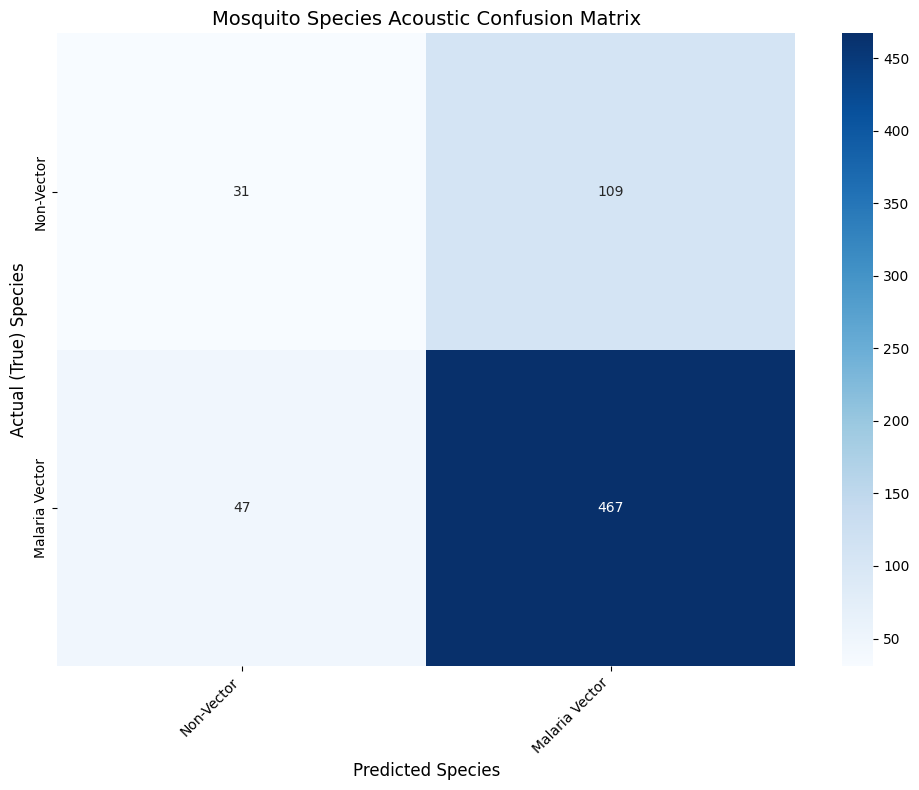


--- Detailed Classification Report ---
                precision    recall  f1-score   support

    Non-Vector       0.40      0.22      0.28       140
Malaria Vector       0.81      0.91      0.86       514

      accuracy                           0.76       654
     macro avg       0.60      0.56      0.57       654
  weighted avg       0.72      0.76      0.73       654



In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Ensure the model is in evaluation mode (turns off Dropout)
model.eval()

all_preds = []
all_labels = []

print("Evaluating model on the testing dataset...")

# Disable gradient calculation for testing to save memory and speed up execution
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# The exact target species from your preprocessing notebook
target_names = ['Non-Vector', 'Malaria Vector']

# Generate and plot the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)

plt.title('Mosquito Species Acoustic Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('Actual (True) Species', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the detailed statistical breakdown
print("\n--- Detailed Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=target_names, zero_division=0))